In [67]:
import os
from collections import namedtuple
from itertools import batched, chain
import json
import math
from multiprocessing import Pool
from pathlib import Path

from datasets import load_from_disk
import matplotlib.pyplot as plt
from nltk.stem.snowball import SnowballStemmer
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import sys
import os
# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from config import CONFIG
from genai_detection.detectors.impostor import ImpostorDetector

In [68]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'Helvetica, sans-serif'
plt.rcParams['font.size'] = 6.5
plt.rcParams['lines.linewidth'] = .5
plt.rcParams['axes.linewidth'] = .5
plt.rcParams['grid.linewidth'] = .25

In [69]:
import re


bytepair_tokenizer = AutoTokenizer.from_pretrained('gpt2', truncation=False, max_length=None, model_max_length=None)


def tokenize_bytepair(text):
    return bytepair_tokenizer.tokenize(text)


def normalize_text(text):
    stemmer = SnowballStemmer('english')
    return ' '.join(stemmer.stem(w) for w in text.lower().split())


def sample_texts(h, m, min_text_ln=500, n_texts=30, seed=42):
    """
    Sample texts from the human and machine datasets, ensuring that each text has at least `min_text_ln` characters.
    Sampling disregards the author frequency, so that each text is sampled independently.
    """
    h = h.query('text.str.len() >= @min_text_ln')
    h = h.sample(n=min(h['id'].count(), n_texts), random_state=seed)

    m = {k: v.query('text.str.len() >= @min_text_ln') for k, v in m.items()}
    m = {k: v.sample(n=min(n_texts, v['id'].count()), random_state=seed) for k, v in m.items()}

    return h, m

def _label_score_pairings(scores, pairing_label):
    # value in brackets is pair ID, rounds are summed up and averaged for X,Y and Y,X in one number each
    # print('scores',scores, len(scores))
    # scores = pd.DataFrame({f'{pairing_label} ({i:04})': [c] for i, c in enumerate(scores)})
    # scores['pairing'] = pairing_label
    # return scores

    return pd.DataFrame({
            'doc_pair_id': [f'{i:04}' for i in range(len(scores))],
            pairing_label: scores
        }).set_index('doc_pair_id')

def reformat_pairing_df(df):
    """
    Converts a long-format _label_score_pairings() output DataFrame
    into a standardized format with 'doc_id' as index and pairing label as column.
    """
    # Extract column name that contains the scores (ignoring the 'pairing' column)
    score_col = next(c for c in df.columns if c != 'pairing')
    
    # Extract the pairing label and doc_id from the column name
    match = re.match(r'(.+?) \((\d{4})\)', score_col)
    if not match:
        raise ValueError(f"Invalid column name format: {score_col}")
    
    pairing_label, doc_id = match.groups()
    
    # Build a new DataFrame with doc_id as index and pairing label as column
    return pd.DataFrame({pairing_label: df[score_col].values}, index=[doc_id])


def impostor(texts_h, texts_m, **unmasking_kwargs):
    impostor_det = ImpostorDetector(strict=True, **unmasking_kwargs)
    # TODO
    with Pool() as pool:
        th = texts_h['text'].map(normalize_text)
        th = th.iloc[:len(th) // 2 * 2]     # Ensure rows are a multiple of two
        l = 'Human / Human'
        scores_h = tqdm(pool.imap(impostor_det.get_scores, batched(th, n=2)), desc=f'Imposter {l}', total=len(th) // 2)
        scores_h = _label_score_pairings(np.squeeze(list(scores_h), axis=1), 'Human / Human')

        scores_m = []
        scores_hm = []
        machine_names = list(texts_m.keys())
        for i, tm in enumerate(texts_m.values()):
            tm = tm['text'].map(normalize_text).iloc[:len(tm) // 2 * 2]
            l = f'{machine_names[i]} / {machine_names[i]}'
            cm = list(tqdm(pool.imap(impostor_det.get_scores, batched(tm, n=2)), desc=f'Imposter {l}', total=len(tm) // 2))
            scores_m.append(_label_score_pairings(np.squeeze(list(cm), axis=1), l))

            n = min(len(th), len(tm)) // 2
            l = f'Human / {machine_names[i]}'
            it = zip(th[:n], tm[:n])
            chm = list(tqdm(pool.imap(impostor_det.get_scores, it), desc=f'Imposter {l}', total=n))
            scores_hm.append(_label_score_pairings(np.squeeze(list(chm), axis=1), l))

        # # FIXME: how are score concatenated?
        print('scores_h', scores_h, len(scores_h))
        print('scores_m', scores_m, len(scores_m))
        print('scores_hm', scores_hm, len(scores_hm))
        # curves = pd.concat([scores_h, *scores_m, *scores_hm])
        # display(curves)
        # curves = pd.melt(curves, var_name='curve_id', value_name='accuracy', id_vars=['pairing'], ignore_index=False)
        # display(curves)
        # curves = curves.reset_index(drop=False, names='doc_pair_id')
        # display(curves)

        dfs = [scores_h, *scores_m, *scores_hm]  # list of _label_score_pairings outputs

        #print('dfs', dfs, len(dfs))

        # Convert and concatenate
        curves = pd.concat([scores_h] + scores_m + scores_hm, axis=1).sort_index()

    return curves


def plot_impostor_curves(curves, max_cols=4, errorbar=('ci', 95), savefig=None):
    # machines = [m.split(' / ', 1)[0] for m in curves['pairing'].unique() if 'Human' not in m]
    # n_cols = min(max_cols, len(machines))
    # n_rows = int(math.ceil(len(machines) / max_cols))
    # pal = sns.color_palette('husl', 3)

    # fig, axs = plt.subplots(n_rows, n_cols, figsize=(1.7 * n_cols, n_rows * 1.45), sharex=True, sharey=True)

    # for i in range(n_cols * n_rows):
    #     ax = axs.flat[i]
    #     if i < len(machines):
    #         p = ['Human / Human', f'{machines[i]} / {machines[i]}', f'Human / {machines[i]}']
    #         _ = p   # Mark used
    #         c = curves.query('pairing in @p')
    #         sns.lineplot(c, x='round', y='accuracy', hue='pairing', style='pairing', palette=pal, errorbar=errorbar, ax=ax)
    #         ax.legend(title=None, frameon=False, borderaxespad=.15)
    #     ax.set_ylim((.5, 1.0))
    #     ax.set_xlim((0, curves['round'].max()))
    #     ax.set_xlabel('Unmasking Rounds')
    #     if i % max_cols == 0:
    #         ax.set_ylabel('Accuracy')

    # plt.tight_layout(pad=0.8)
    # plt.subplots_adjust(wspace=.025, hspace=.05)
    # if savefig:
    #     Path(savefig).parent.mkdir(parents=True, exist_ok=True)
    #     plt.savefig(savefig)
    # plt.show()
    # FIXME: 
    # Plot
    plt.figure(figsize=(12, 6))
    for col in curves.columns:
        plt.plot(curves.index, curves[col], label=col)
    plt.xticks(rotation=45)

    plt.title('Impostor Score Over Document Pairs (High == Same Author)\ndoc_pair_ids are not the same document across model configurations')
    plt.xlabel('Document Pair ID')
    plt.ylabel('Score')

    plt.legend(title='Pairing', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

    if savefig:
        plt.savefig(savefig)
    plt.show()
    


TTestResult = namedtuple('TTestResult', ['t', 'dof', 'p', 'd'])


def t_test(a, b):
    t, p = stats.ttest_ind(a, b)
    d = t * np.sqrt((len(a) + len(b)) / (len(a) * len(b)))
    return TTestResult(t=t, dof=len(a) + len(b) - 2, p=p, d=d)


def t_test_str(t: TTestResult, correction_factor=1):
    p_str = f'< {.001:>5}' if t.p < .001 else f'= {t.p:>5,.3f}'
    if correction_factor:
        p_corr = t.p * correction_factor
        if p_corr >= 1.:
            p_str += ', p[bf] = 1.00'
        else:
            p_str += ', p[bf] ' + (f'< {.001:>5}' if p_corr < .001 else f'= {p_corr:>5,.3f}')
    return f't({t.dof:,}) = {t.t:>6,.2f}, p {p_str.replace('0.', '.')}, d = {t.d:>4,.1f}'


def print_t_test_for_curves(curves, min_round=10):
    pairings = [p for p in curves['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(curves.query('round >= @min_round and pairing == "Human / Human"')['accuracy'].dropna(),
                   curves.query('round >= @min_round and pairing == @pairing')['accuracy'].dropna())
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')


def print_t_test_for_compression(cbc):
    pairings = [p for p in cbc['pairing'].unique() if not p.startswith('Human /')]
    print('Differences from Human / Human:')
    for pairing in pairings:
        t = t_test(cbc.query('pairing == "Human / Human"')['score'],
                   cbc.query('pairing == @pairing')['score'])
        print(f'  {pairing:<{max(len(p_) for p_ in pairings) + 1}}: {t_test_str(t, len(pairings))}')

# PAN

In [70]:
from collections import Counter


def split_pan_ds_dataset_by_model(df, seed=42):
    df_human = df.query('model == "human"').sample(frac=1, random_state=seed)
    df_machine = {
        'gpt-4-turbo-paraphrase': df.query('model == "gpt-4-turbo-paraphrase"').sample(frac=1, random_state=seed),
        'gemini-pro': df.query('model == "gemini-pro"').sample(frac=1, random_state=seed),
        'gpt-4-turbo': df.query('model == "gpt-4-turbo"').sample(frac=1, random_state=seed),
        'gemini-pro-paraphrase': df.query('model == "gemini-pro-paraphrase"').sample(frac=1, random_state=seed),
    }
    return df_human, df_machine

ds_pan = load_from_disk(os.path.join(os.path.abspath(".."), CONFIG.PATH2PAN25))['train'].to_pandas()
# label is string 'human' for human texts, but we want to have it as 0
ds_pan['label'] = ds_pan['label'].map({'human': 0, 'machine': 1})
print('Unique Models:', list(ds_pan['model'].unique()))
df_pan_h, df_pan_m = split_pan_ds_dataset_by_model(ds_pan)


display(df_pan_h.head())

assert df_pan_h['label'].count() > 0 , "No human texts found in PAN dataset"
assert df_pan_h['label'].sum() == 0, "PAN dataset contains human texts with labelled as AI-generated"

sample_pan = sample_texts(df_pan_h, df_pan_m, n_texts=400)

Unique Models: ['human', 'gemini-pro-paraphrase', 'gpt-4-turbo-paraphrase', 'gemini-pro', 'gpt-4-turbo']


,id,text,label,model
746,news-2021-01-01-2021-12-31-kamalaharrisvicepre...,Kamala Harris to tell UN body it’s time to pre...,0,human
56,news-2021-01-01-2021-12-31-covid19/art-035,Classification of Omicron (B.1.1.529): SARS-Co...,0,human
684,news-2021-01-01-2021-12-31-cnnchriscuomo/art-017,Reports say CNN’s Chris Cuomo got special COVI...,0,human
896,news-2021-01-01-2021-12-31-colonialpipelinehac...,Colonial Pipeline ransomware attack highlights...,0,human
723,news-2021-01-01-2021-12-31-cnnchriscuomo/art-030,New York Gov. Andrew Cuomo will resign\n\nCNN ...,0,human


In [71]:
# one elmenent = averaged score of X,Y and Y,X pair (score=number of rounds where the candidate was the most similar)
scores_pan_top_250 = impostor(*sample_pan, top_n=250, portion_delete=0.5, rounds=25, shared_vocab_only=True)

Imposter Human / Human:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter gpt-4-turbo-paraphrase / gpt-4-turbo-paraphrase:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter Human / gpt-4-turbo-paraphrase:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter gemini-pro / gemini-pro:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter Human / gemini-pro:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter gpt-4-turbo / gpt-4-turbo:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter Human / gpt-4-turbo:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter gemini-pro-paraphrase / gemini-pro-paraphrase:   0%|          | 0/200 [00:00<?, ?it/s]

Imposter Human / gemini-pro-paraphrase:   0%|          | 0/200 [00:00<?, ?it/s]

scores_h              Human / Human
doc_pair_id               
0000                  12.5
0001                  12.5
0002                  19.0
0003                  13.0
0004                   0.0
...                    ...
0195                   0.0
0196                  10.5
0197                   0.0
0198                  11.0
0199                  12.5

[200 rows x 1 columns] 200
scores_m [             gpt-4-turbo-paraphrase / gpt-4-turbo-paraphrase
doc_pair_id                                                 
0000                                                    13.0
0001                                                    10.0
0002                                                     0.0
0003                                                     0.0
0004                                                    12.5
...                                                      ...
0195                                                     0.0
0196                                                 

In [72]:
scores_pan_top_250

,Human / Human,gpt-4-turbo-paraphrase / gpt-4-turbo-paraphrase,gemini-pro / gemini-pro,gpt-4-turbo / gpt-4-turbo,gemini-pro-paraphrase / gemini-pro-paraphrase,Human / gpt-4-turbo-paraphrase,Human / gemini-pro,Human / gpt-4-turbo,Human / gemini-pro-paraphrase
doc_pair_id,,,,,,,,,
0000,12.5,13.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0
0001,12.5,10.0,18.5,0.0,14.0,12.5,0.0,18.0,20.5
0002,19.0,0.0,0.0,18.0,20.0,13.5,0.0,0.0,0.0
0003,13.0,0.0,18.5,17.0,0.0,13.5,14.5,12.5,13.0
0004,0.0,12.5,0.0,0.0,0.0,0.0,0.0,18.5,0.0
...,...,...,...,...,...,...,...,...,...
0195,0.0,0.0,14.5,12.5,0.0,13.5,0.0,0.0,12.0
0196,10.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0197,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


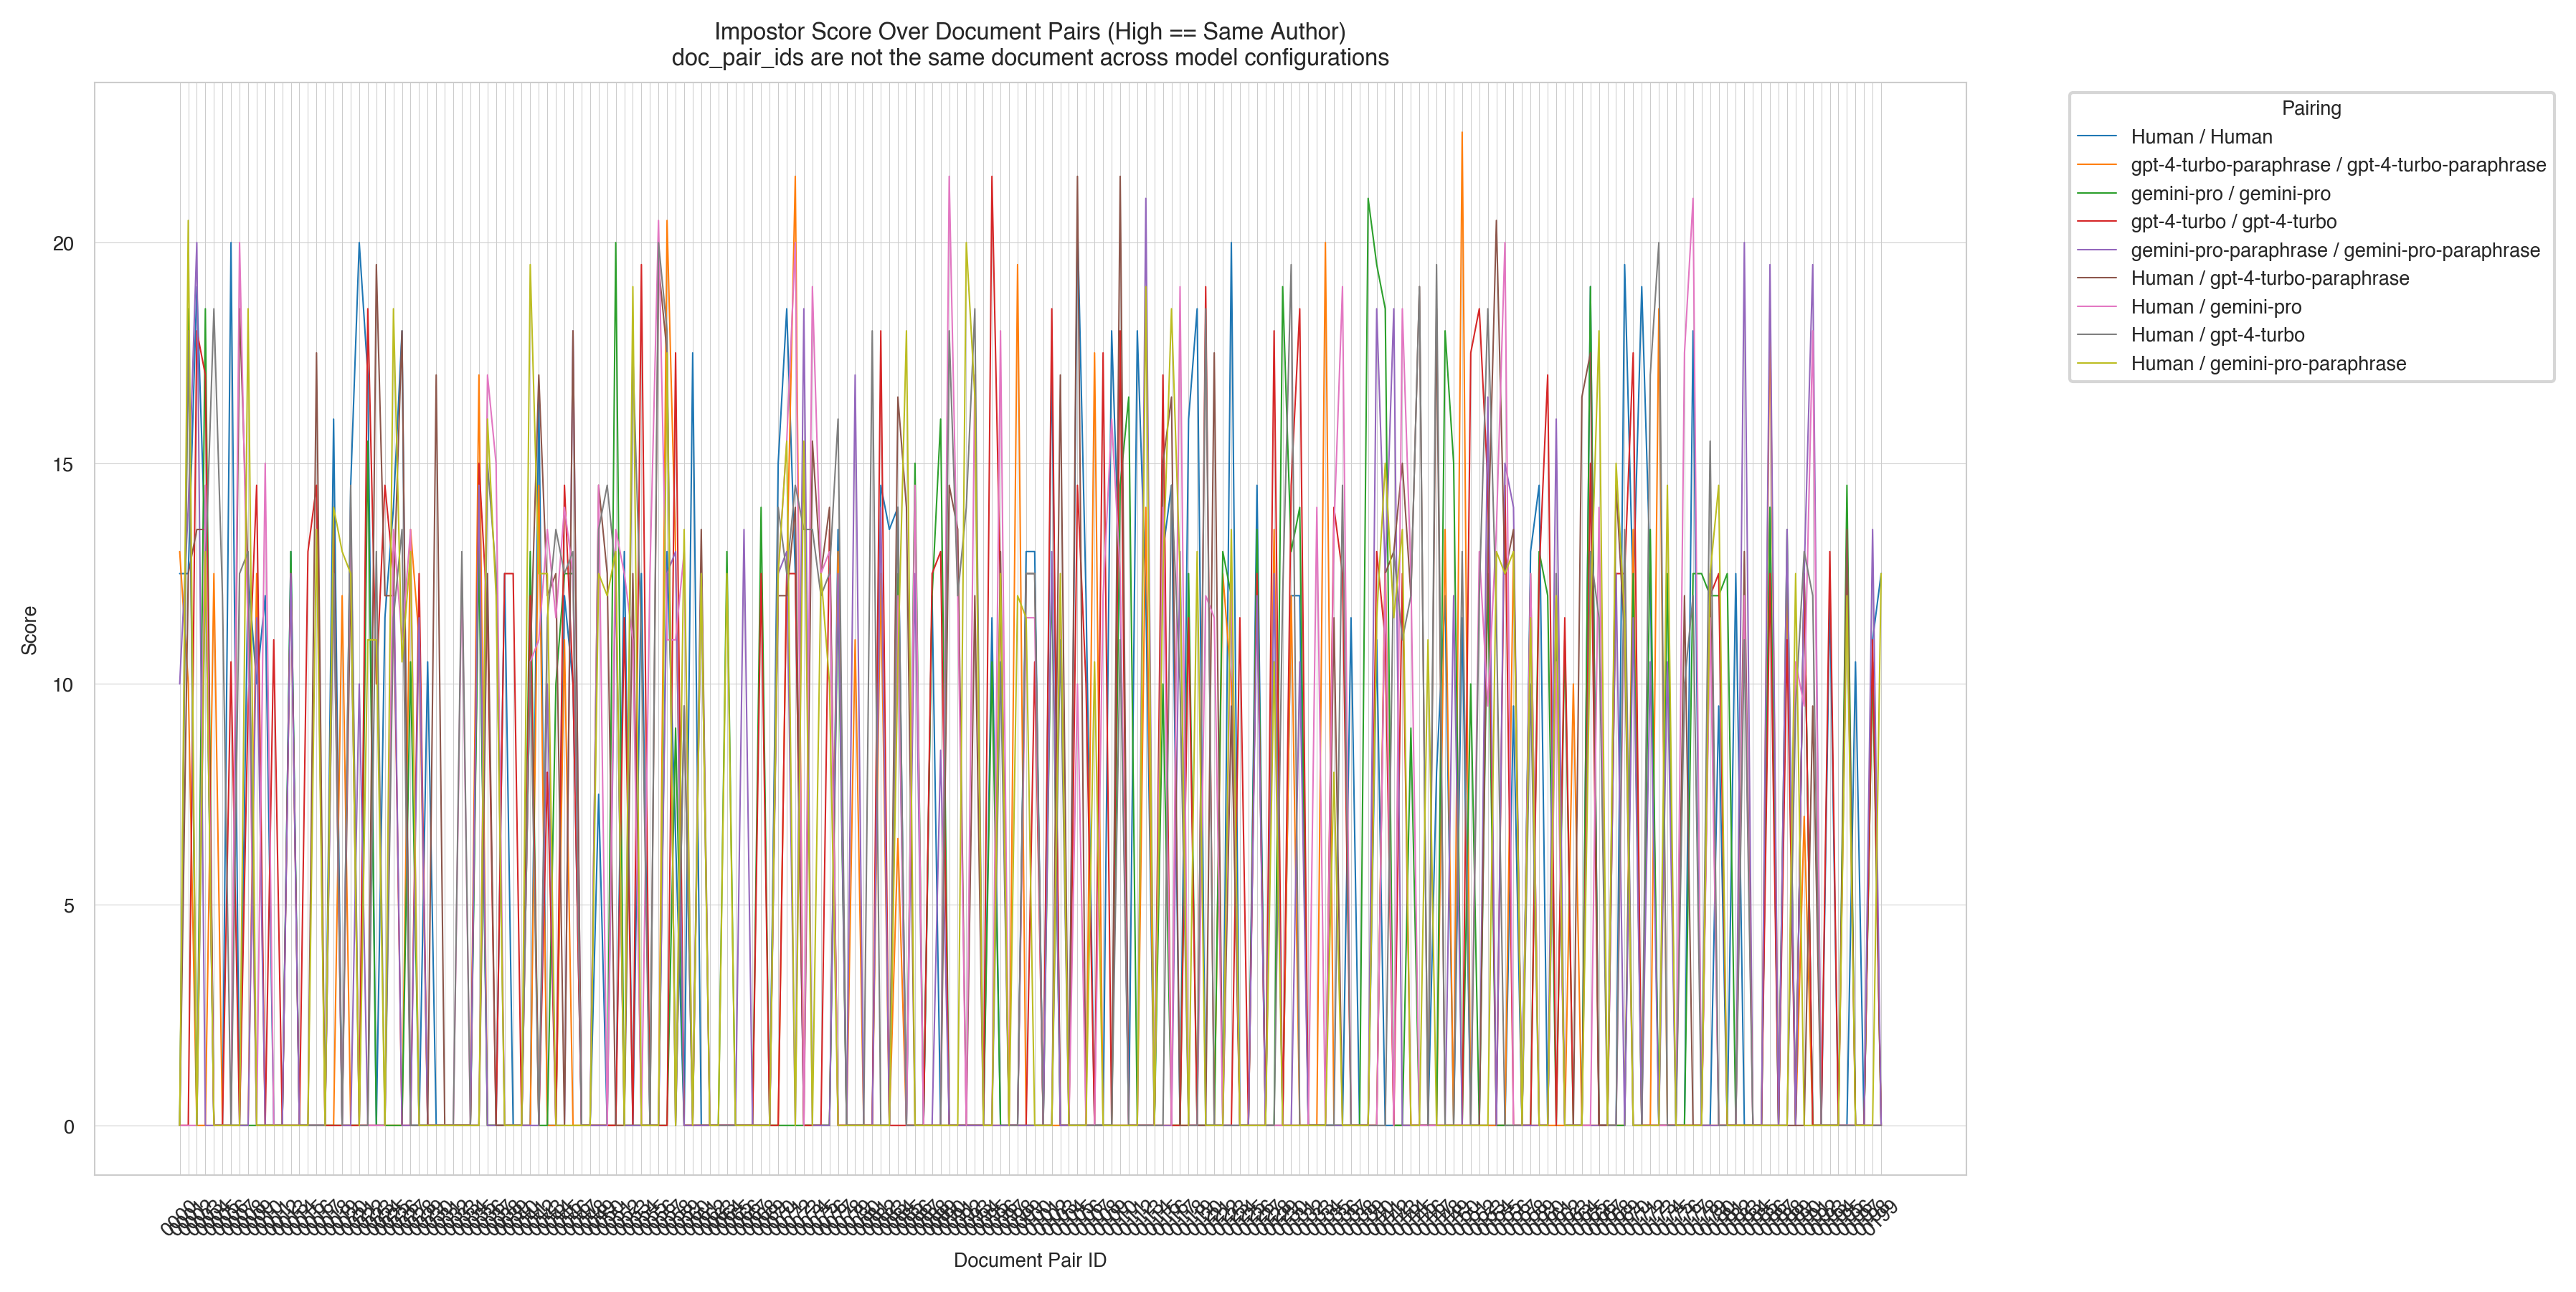

In [73]:
# assuming df_scores is your wide-format scores table
plot_impostor_curves(scores_pan_top_250)